In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy import stats

df = pd.read_csv("amz_uk_price_prediction_dataset.csv")  # change filename if needed
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [3]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [4]:
crosstab = pd.crosstab(df["category"], df["isBestSeller"])
crosstab.head()

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


In [5]:
best_seller_prop = crosstab.div(crosstab.sum(axis=1), axis=0)

# if True/False values exist
best_seller_prop = best_seller_prop.sort_values(by=True, ascending=False)
best_seller_prop.head(10)

isBestSeller,False,True
category,,
Grocery,0.941865,0.058135
Smart Home Security & Lighting,0.942308,0.057692
Health & Personal Care,0.942314,0.057686
Mobile Phone Accessories,0.957529,0.042471
Power & Hand Tools,0.964661,0.035339
"Billiard, Snooker & Pool",0.967871,0.032129
Pet Supplies,0.969800,0.030200
Home Brewing & Wine Making,0.971545,0.028455
Wind Instruments,0.972000,0.028000


In [6]:
chi2, p, dof, expected = chi2_contingency(crosstab)
print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 36540.20270061387
p-value: 0.0


In [7]:
n = crosstab.to_numpy().sum()
min_dim = min(crosstab.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print("Cramér's V:", cramers_v)

Cramér's V: 0.1222829439760564


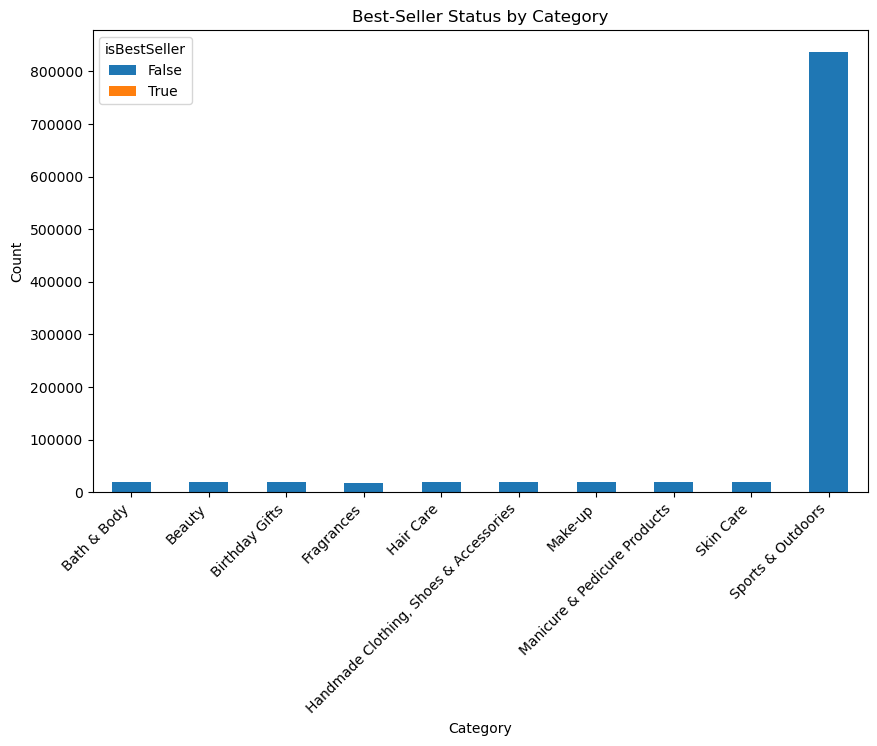

In [8]:
top_categories = df["category"].value_counts().head(10).index
crosstab_top = pd.crosstab(
    df[df["category"].isin(top_categories)]["category"],
    df[df["category"].isin(top_categories)]["isBestSeller"]
)

crosstab_top.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Best-Seller Status by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

In [9]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_no_outliers = df[(df["price"] >= lower) & (df["price"] <= upper)]
df_no_outliers.shape

(2115963, 9)

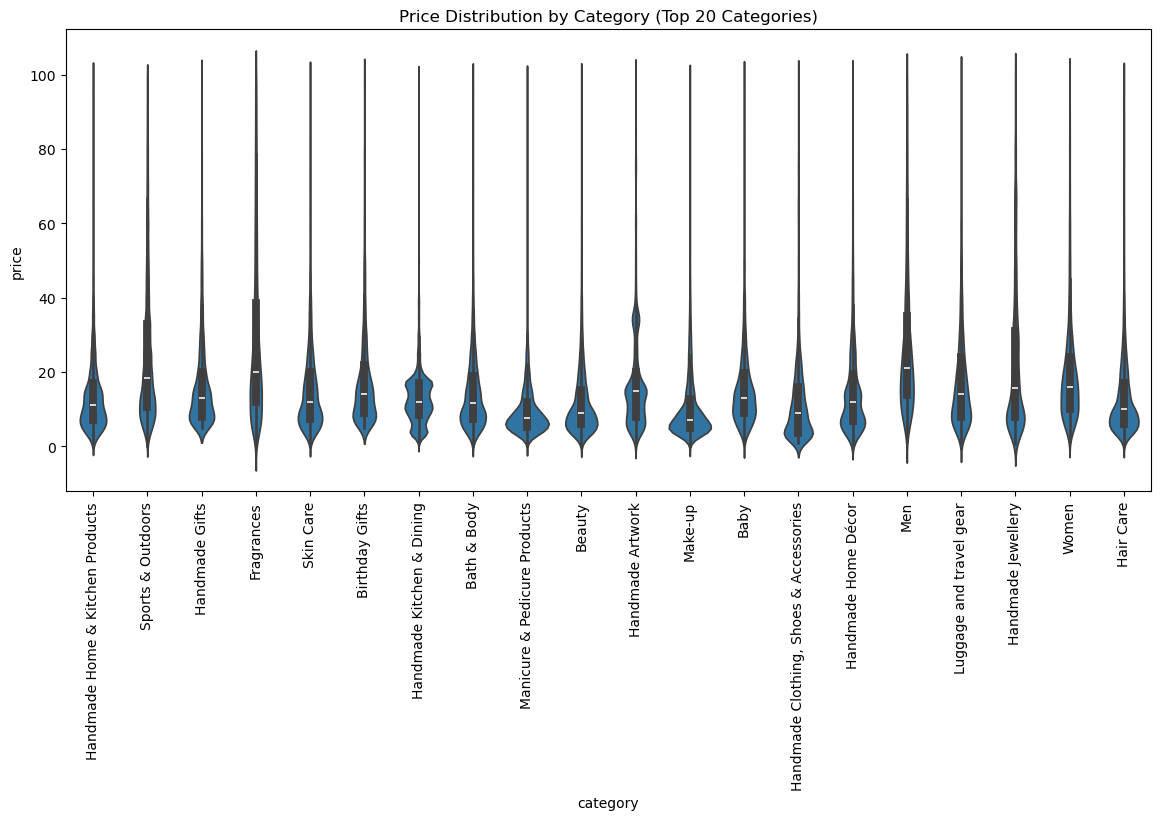

In [10]:
top20_categories = df_no_outliers["category"].value_counts().head(20).index
df_top20 = df_no_outliers[df_no_outliers["category"].isin(top20_categories)]

plt.figure(figsize=(14,6))
sns.violinplot(data=df_top20, x="category", y="price")
plt.xticks(rotation=90)
plt.title("Price Distribution by Category (Top 20 Categories)")
plt.show()

In [11]:
median_price_by_category = df_no_outliers.groupby("category")["price"].median().sort_values(ascending=False)
median_price_by_category.head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

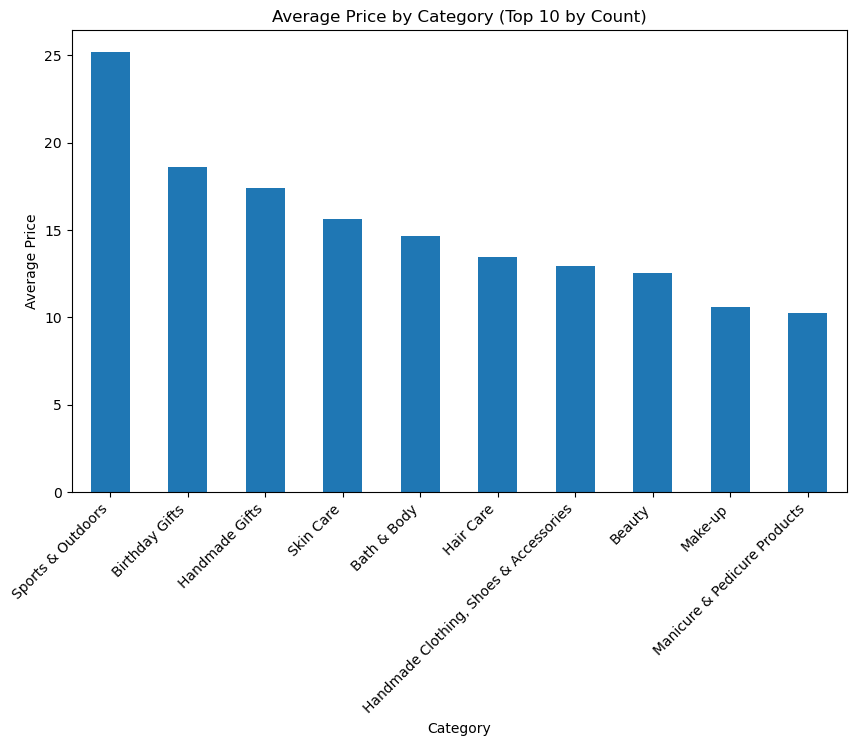

In [12]:
top10_categories = df_no_outliers["category"].value_counts().head(10).index
avg_price_top10 = (
    df_no_outliers[df_no_outliers["category"].isin(top10_categories)]
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

avg_price_top10.plot(kind="bar", figsize=(10,6))
plt.title("Average Price by Category (Top 10 by Count)")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha="right")
plt.show()